# 💳 Scoring crédit — Explicabilité & Biais
## Notebook 3/3

**Auteur :** Diogo Almeida
**Objectif :** Expliquer les décisions du modèle (SHAP/LIME) et analyser ses biais.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import shap
import lime
import lime.lime_tabular
from fairlearn.metrics import MetricFrame, demographic_parity_difference
from sklearn.metrics import accuracy_score, f1_score
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import joblib
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_PROCESSED = Path('..') / 'data' / 'processed'
MODELS = Path('..') / 'models'
ASSETS = Path('..') / 'assets'

## 0. Chargement

In [2]:
# Charger données et modèle
df = pd.read_csv(DATA_PROCESSED / 'credit_clean.csv')
df_encoded = pd.read_csv(DATA_PROCESSED / 'credit_encoded.csv')
best_model = joblib.load(MODELS / 'best_model.pkl')
feature_cols = joblib.load(MODELS / 'feature_cols.pkl')

X = df_encoded[feature_cols].copy()
y = df_encoded['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Garder les index pour retrouver les données non-encodées plus tard
test_indices = X_test.index

print(f'Modèle : {type(best_model).__name__}')
print(f'Features : {len(feature_cols)}')
print(f'Test : {len(X_test)} lignes')

Modèle : RandomForestClassifier
Features : 24
Test : 200 lignes


## 1. Explicabilité globale — SHAP

In [3]:
# Calculer les SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values_raw = explainer.shap_values(X_test)

# Adapter le format selon le modèle
# Certains modèles retournent une liste [classe_0, classe_1]
# D'autres un array 3D (n_samples, n_features, n_classes)
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]  # Classe 1 = défaut
    print(f'Format : list de {len(shap_values_raw)} arrays')
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_vals = shap_values_raw[:, :, 1]  # Classe 1
    print(f'Format : array 3D {shap_values_raw.shape}')
else:
    shap_vals = shap_values_raw
    print(f'Format : array 2D')

# Expected value (base value) — même logique
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]  # Classe 1

print(f'SHAP values : {shap_vals.shape}')
print(f'Base value : {base_value:.4f}')

Format : array 3D (200, 24, 2)
SHAP values : (200, 24)
Base value : 0.3003


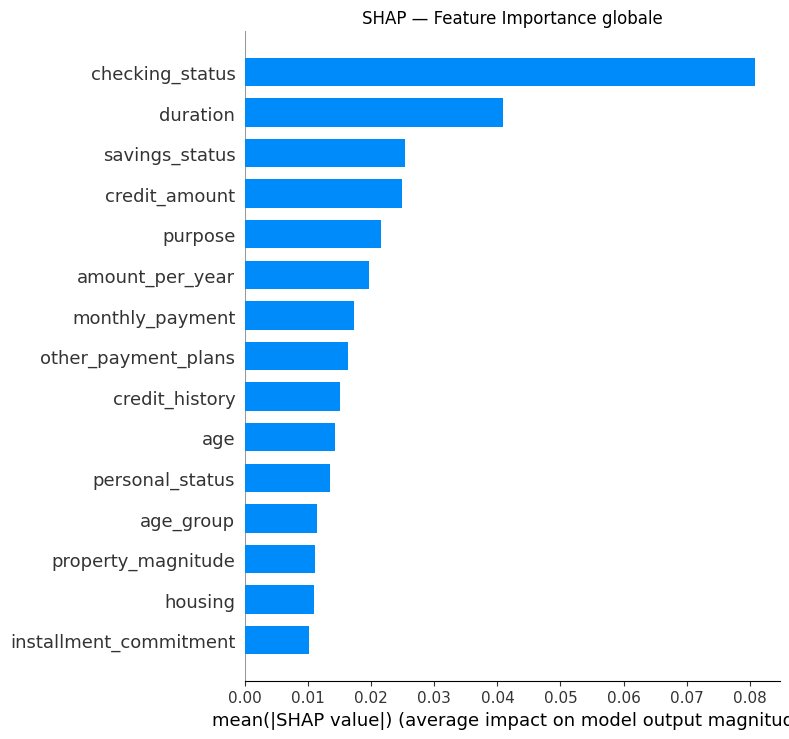

In [4]:
# Feature importance globale
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test, plot_type='bar', show=False, max_display=15)
plt.title('SHAP — Feature Importance globale')
plt.tight_layout()
plt.savefig(ASSETS / '05_shap_importance.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

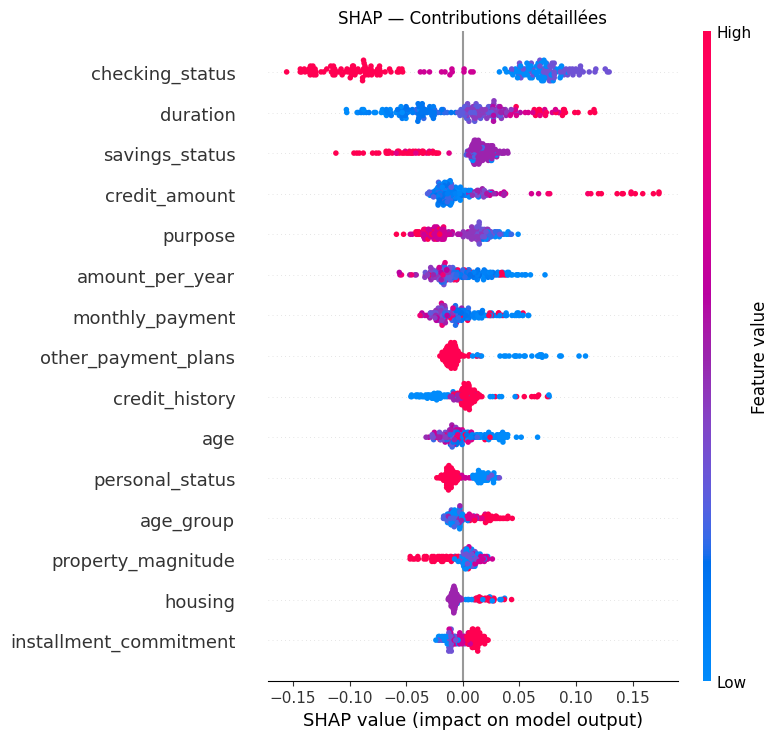

In [5]:
# Beeswarm — contributions détaillées
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test, show=False, max_display=15)
plt.title('SHAP — Contributions détaillées')
plt.tight_layout()
plt.savefig(ASSETS / '06_shap_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

## 2. Explicabilité locale — Waterfall (un refus de crédit)

Clients refusés : 32 / 200

Client refusé (position 23) :
Top 5 facteurs de risque :
  checking_status: +0.088 (↑ augmente le risque)
  duration: +0.047 (↑ augmente le risque)
  age: +0.034 (↑ augmente le risque)
  property_magnitude: -0.027 (↓ diminue le risque)
  savings_status: +0.025 (↑ augmente le risque)


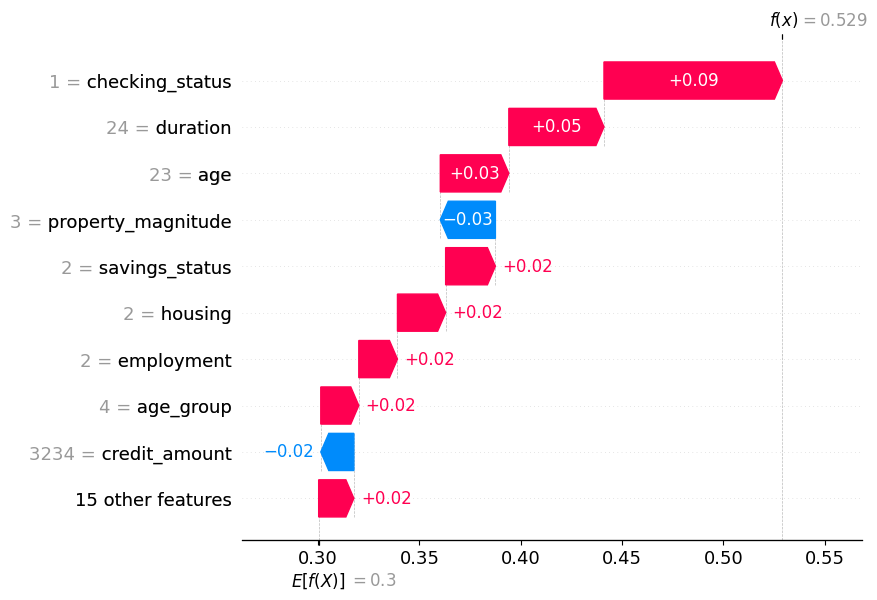

<Figure size 640x480 with 0 Axes>

In [6]:
# Trouver un client refusé
y_pred = best_model.predict(X_test)
refused_mask = y_pred == 1
refused_positions = np.where(refused_mask)[0]

print(f'Clients refusés : {refused_mask.sum()} / {len(y_pred)}')

if len(refused_positions) > 0:
    pos = refused_positions[0]  # Position dans X_test
    
    print(f'\nClient refusé (position {pos}) :')
    print(f'Top 5 facteurs de risque :')
    
    contributions = pd.Series(shap_vals[pos], index=feature_cols)
    for feat, val in contributions.abs().nlargest(5).items():
        direction = '↑ augmente' if contributions[feat] > 0 else '↓ diminue'
        print(f'  {feat}: {contributions[feat]:+.3f} ({direction} le risque)')
    
    # Waterfall plot
    shap.waterfall_plot(shap.Explanation(
        values=shap_vals[pos],
        base_values=base_value,
        data=X_test.iloc[pos],
        feature_names=feature_cols,
    ))
    plt.savefig(ASSETS / '07_shap_waterfall_refus.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
else:
    print('Aucun client refusé dans le test set')

## 3. Explicabilité locale — LIME

LIME — Client refusé (position 23)
Proba défaut : 0.529


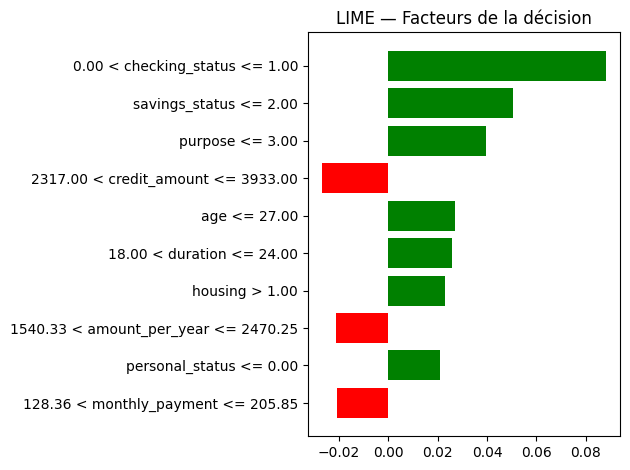

In [7]:
# LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_cols,
    class_names=['Bon payeur', 'Mauvais payeur'],
    mode='classification',
    random_state=42,
)

if len(refused_positions) > 0:
    pos = refused_positions[0]
    
    exp = lime_explainer.explain_instance(
        X_test.iloc[pos].values,
        best_model.predict_proba,
        num_features=10,
    )
    
    print(f'LIME — Client refusé (position {pos})')
    print(f'Proba défaut : {best_model.predict_proba(X_test.iloc[pos:pos+1])[0][1]:.3f}')
    
    fig = exp.as_pyplot_figure()
    plt.title('LIME — Facteurs de la décision')
    plt.tight_layout()
    plt.savefig(ASSETS / '08_lime_refus.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

## 4. Analyse de biais — Fairlearn

Le modèle traite-t-il tous les groupes équitablement ?

In [8]:
# Récupérer les attributs sensibles depuis le dataset non-encodé
df_test = df.iloc[test_indices].copy()

# Sexe (extrait de personal_status dans le notebook 1)
if 'is_male' in df_test.columns:
    sensitive_sex = df_test['is_male'].map({1: 'Homme', 0: 'Femme'})
    sensitive_sex = sensitive_sex.fillna('Inconnu')
else:
    sensitive_sex = pd.Series('Inconnu', index=df_test.index)

# Age
if 'age_group' in df_test.columns:
    sensitive_age = df_test['age_group'].astype(str)
else:
    sensitive_age = pd.Series('Inconnu', index=df_test.index)

# Réindexer pour matcher y_test et y_pred
sensitive_sex = sensitive_sex.values
sensitive_age = sensitive_age.values

print(f'Attributs sensibles :')
print(f'  Sexe : {pd.Series(sensitive_sex).value_counts().to_dict()}')
print(f'  Age : {pd.Series(sensitive_age).value_counts().to_dict()}')

Attributs sensibles :
  Sexe : {'Homme': 139, 'Femme': 61}
  Age : {'25-35': 66, '35-45': 45, '<25': 44, '45-55': 25, '55+': 20}


### 4.1 Biais par sexe

In [9]:
# Métriques par groupe — Sexe
metric_frame_sex = MetricFrame(
    metrics={'accuracy': accuracy_score, 'f1': f1_score},
    y_true=y_test.values,
    y_pred=y_pred,
    sensitive_features=sensitive_sex,
)

print('=== MÉTRIQUES PAR SEXE ===')
display(metric_frame_sex.by_group)
print(f'\nDifférence entre groupes :')
display(metric_frame_sex.difference())

=== MÉTRIQUES PAR SEXE ===


,accuracy,f1
sensitive_feature_0,,
Femme,0.786885,0.628571
Homme,0.776978,0.456140



Différence entre groupes :


accuracy    0.009907
f1          0.172431
dtype: float64

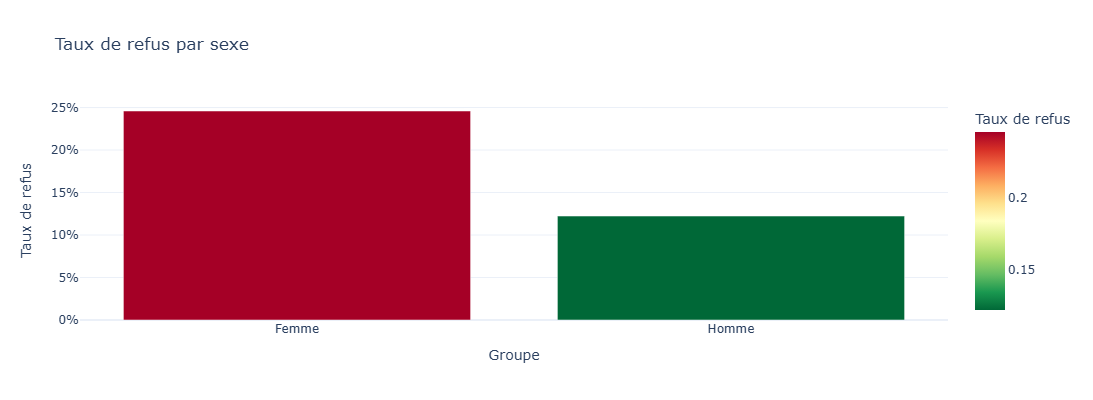

In [10]:
# Taux de refus par sexe
refusal_sex = pd.DataFrame({'Sexe': sensitive_sex, 'Refuse': y_pred})
refusal_rate = refusal_sex.groupby('Sexe')['Refuse'].mean().reset_index()
refusal_rate.columns = ['Groupe', 'Taux_Refus']

fig = px.bar(refusal_rate, x='Groupe', y='Taux_Refus',
    title='Taux de refus par sexe',
    labels={'Taux_Refus': 'Taux de refus'},
    color='Taux_Refus', color_continuous_scale='RdYlGn_r',
    template='plotly_white', height=400)
fig.update_layout(yaxis_tickformat='.0%')
fig.show()
fig.write_image(ASSETS / '09_biais_sexe.png', scale=2)

### 4.2 Biais par âge

=== MÉTRIQUES PAR ÂGE ===


,accuracy,f1
sensitive_feature_0,,
25-35,0.787879,0.588235
35-45,0.755556,0.153846
45-55,0.800000,0.444444
55+,0.950000,0.666667
<25,0.704545,0.606061


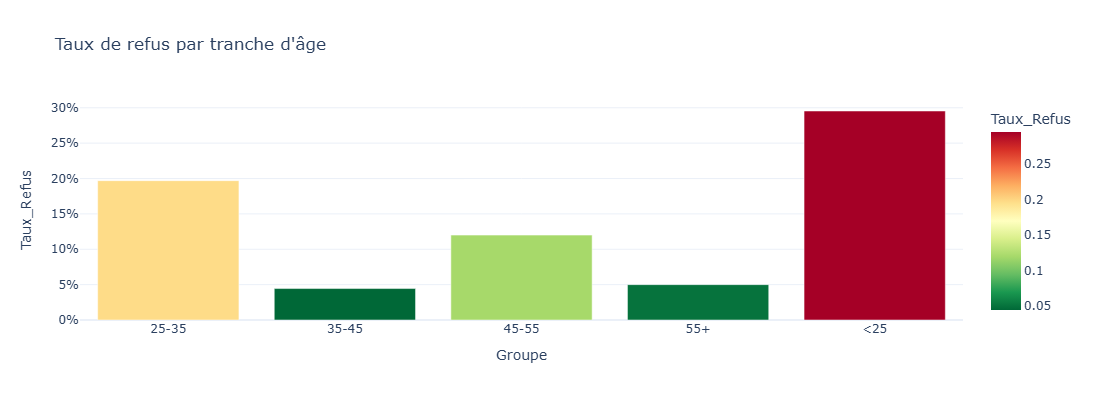

In [11]:
# Métriques par tranche d'âge
metric_frame_age = MetricFrame(
    metrics={'accuracy': accuracy_score, 'f1': f1_score},
    y_true=y_test.values,
    y_pred=y_pred,
    sensitive_features=sensitive_age,
)

print('=== MÉTRIQUES PAR ÂGE ===')
display(metric_frame_age.by_group)

# Taux de refus par âge
refusal_age = pd.DataFrame({'Age': sensitive_age, 'Refuse': y_pred})
refusal_rate_age = refusal_age.groupby('Age')['Refuse'].mean().reset_index()
refusal_rate_age.columns = ['Groupe', 'Taux_Refus']

fig = px.bar(refusal_rate_age, x='Groupe', y='Taux_Refus',
    title="Taux de refus par tranche d'âge",
    color='Taux_Refus', color_continuous_scale='RdYlGn_r',
    template='plotly_white', height=400)
fig.update_layout(yaxis_tickformat='.0%')
fig.show()
fig.write_image(ASSETS / '10_biais_age.png', scale=2)

## 5. Synthèse

In [12]:
print('=' * 60)
print('SYNTHÈSE — EXPLICABILITÉ & BIAIS')
print('=' * 60)

print(f'\n1. EXPLICABILITÉ')
print(f'   Top 3 features globales (SHAP) :')
shap_importance = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_cols)
for feat, imp in shap_importance.nlargest(3).items():
    print(f'     - {feat} (importance : {imp:.3f})')

print(f'\n2. BIAIS PAR SEXE')
try:
    dpd = demographic_parity_difference(y_test.values, y_pred, sensitive_features=sensitive_sex)
    print(f'   Demographic Parity Difference : {dpd:.3f}')
    if abs(dpd) > 0.1:
        print(f'   ⚠️  Biais significatif détecté (seuil : 0.10)')
    else:
        print(f'   ✓ Pas de biais significatif (seuil : 0.10)')
except Exception as e:
    print(f'   Calcul impossible : {e}')

print(f'\n3. RECOMMANDATIONS')
print(f'   - Chaque refus explicable par ses 5 facteurs principaux (SHAP waterfall)')
print(f'   - LIME fournit des explications textuelles complémentaires')
print(f'   - Le biais par sexe/âge doit être monitoré en production')
print(f'   - Envisager une mitigation (Fairlearn ThresholdOptimizer) si biais confirmé')

SYNTHÈSE — EXPLICABILITÉ & BIAIS

1. EXPLICABILITÉ
   Top 3 features globales (SHAP) :
     - checking_status (importance : 0.081)
     - duration (importance : 0.041)
     - savings_status (importance : 0.025)

2. BIAIS PAR SEXE
   Demographic Parity Difference : 0.124
   ⚠️  Biais significatif détecté (seuil : 0.10)

3. RECOMMANDATIONS
   - Chaque refus explicable par ses 5 facteurs principaux (SHAP waterfall)
   - LIME fournit des explications textuelles complémentaires
   - Le biais par sexe/âge doit être monitoré en production
   - Envisager une mitigation (Fairlearn ThresholdOptimizer) si biais confirmé


---

*Notebook réalisé par Diogo Almeida — Septembre 2026*